In [12]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd
import numpy as np


In [14]:
df_vendas = pd.read_csv('01.amazon_sales_dataset.csv')
df_vendas.columns

Index(['order_id', 'order_date', 'ship_date', 'delivery_date', 'order_status',
       'customer_id', 'customer_name', 'country', 'state', 'city',
       'product_id', 'product_name', 'category', 'sub_category', 'brand',
       'quantity', 'unit_price', 'discount', 'shipping_cost', 'total_sales',
       'payment_method'],
      dtype='str')

In [15]:
df_vendas.dtypes

order_id              str
order_date            str
ship_date             str
delivery_date         str
order_status          str
customer_id           str
customer_name         str
country               str
state                 str
city                  str
product_id            str
product_name          str
category              str
sub_category          str
brand                 str
quantity            int64
unit_price        float64
discount          float64
shipping_cost     float64
total_sales       float64
payment_method        str
dtype: object

In [16]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        10000 non-null  str    
 1   order_date      10000 non-null  str    
 2   ship_date       10000 non-null  str    
 3   delivery_date   10000 non-null  str    
 4   order_status    10000 non-null  str    
 5   customer_id     10000 non-null  str    
 6   customer_name   10000 non-null  str    
 7   country         10000 non-null  str    
 8   state           10000 non-null  str    
 9   city            10000 non-null  str    
 10  product_id      10000 non-null  str    
 11  product_name    10000 non-null  str    
 12  category        10000 non-null  str    
 13  sub_category    10000 non-null  str    
 14  brand           10000 non-null  str    
 15  quantity        10000 non-null  int64  
 16  unit_price      10000 non-null  float64
 17  discount        10000 non-null  float64
 18

In [17]:
coluna_alvo = 'total_sales'

assimetria = df_vendas[coluna_alvo].skew()
total_vendas = df_vendas[coluna_alvo].sum()
media_valor_vendas = df_vendas[coluna_alvo].mean()
venda_minima = df_vendas[coluna_alvo].min()
venda_maxima = df_vendas[coluna_alvo].max()
amplitude_vendas = venda_maxima - venda_minima

In [18]:
q1 = np.percentile(df_vendas[coluna_alvo], 25)
q2 = np.percentile(df_vendas[coluna_alvo], 50)
q3 = np.percentile(df_vendas[coluna_alvo], 75) 

In [19]:
delta_media_mediana = media_valor_vendas - q2
distancia_percentual = media_valor_vendas / q2

In [20]:
df_vendas[coluna_alvo].skew()

np.float64(0.9635357597583109)

In [21]:
print('---- Relatorio Estatísticos de Negócio ----')

print(f'A média de vendas é de R$ {media_valor_vendas:.2f}')
print(f'A mediana (valor central) é de R$ {q2:.2f}')
print(f'O Delta (Diferença) entre a média e a mediana é de R$ {delta_media_mediana:.2f}')
print('----Análise Comporttamental----')
print(f'A distância percentual entre a média e a mediana é de {distancia_percentual:.2f} vezes')

if abs(distancia_percentual) < 0.10:
    print(f'INFERÊNCIA: Baixa dispersão. A média é confiável para representar a coluna')

elif abs(distancia_percentual) < 0.25:
    print(f'INFERÊNCIA: Dispersão moderada. A média pode ser influenciada por valores extremos, Fique atento a valores extremos.')

print(f'O coeficiente de assimetria (skewness) é de {assimetria:.2f}')

if assimetria > 0.5:
    print(f'INFERÊNCIA: Assimetria positiva. Nossas vendas tem uma cauda longa para a direita. Os grandes clientes são minoria, todavia eles faturam valores expressivos puxando a média para cima.')

elif assimetria < -0.5:
    print(f'INFERÊNCIA: Assimetria negativa. Nossas vendas tem uma cauda longa para a esquerda. O valor médio está sendo puxado para baixo por um grande volume de vendas baratas.')

else:
    print(f'INFERÊNCIA (Simétrica): Distribuição Equilibrada. A média e medianas estão próximas')


---- Relatorio Estatísticos de Negócio ----
A média de vendas é de R$ 64212.91
A mediana (valor central) é de R$ 50287.18
O Delta (Diferença) entre a média e a mediana é de R$ 13925.73
----Análise Comporttamental----
A distância percentual entre a média e a mediana é de 1.28 vezes
O coeficiente de assimetria (skewness) é de 0.96
INFERÊNCIA: Assimetria positiva. Nossas vendas tem uma cauda longa para a direita. Os grandes clientes são minoria, todavia eles faturam valores expressivos puxando a média para cima.


In [22]:

curtose = df_vendas[coluna_alvo].kurtosis()

In [23]:
# Medidas de dispersão

# 1. Amplitude
amplitude = venda_maxima - venda_minima

# 2. Variância e Desvio Padrão
variancia = df_vendas[coluna_alvo].var()
desvio_padrao = df_vendas[coluna_alvo].std()

# 3. IQR -> 50% internos dos dados (25%~75%)
# Muito robusto para outliers
iqr = q3 - q1

# 4. Coeficiente de Variação (CV)
# Muito usado para comparar volatilidades de grandezas diferentes
# Obs: Multiplicamos por 100 para expressar o resultado em porcentagem
cv = (desvio_padrao / media_valor_vendas)*100

In [24]:
print(f'---Dispersão---')
print(f'Amplitude Total de Vendas: R$ {amplitude_vendas:.2f}')
print(f'Variância de Vendas: {variancia:.2f}')
print(f'Desvio Padrão de Vendas: {desvio_padrao:.2f}')
print(f'Intervalo Interquartil (IQR): {iqr:.2f}')
print(f'INFERÊNCIA: Esta é a variação de gastos do nosso consumidor padrão, ignorando clientes que compram muito pouco ou muito caro.')
print(f'Coeficiente de Variação de Vendas: {cv:.2f}%')
if cv > 30:
    print(f'INFERÊNCIA: Alta Variabilidade. As vendas são altamente dispersas em relação à média, indicando uma grande diversidade de valores de vendas.')
else:
    print(f'INFERÊNCIA: Baixa Variabilidade. As vendas são relativamente consistentes em relação à média, indicando uma menor diversidade de valores de vendas.')
print(f'Curtose de Vendas: {curtose:.2f}')
if curtose > 0.5:
    print(f'INFERÊNCIA: Leptocúrtica. Pico agudo, caudas grossas')
    print('Sobre o negócio: A maioria das vendas estão concentradas em torno da média, com uma altissima probabilidade de eventos extremos (outliers) que podem representar grandes clientes ou vendas atípicas.')

---Dispersão---
Amplitude Total de Vendas: R$ 248845.59
Variância de Vendas: 2600248832.58
Desvio Padrão de Vendas: 50992.64
Intervalo Interquartil (IQR): 69380.70
INFERÊNCIA: Esta é a variação de gastos do nosso consumidor padrão, ignorando clientes que compram muito pouco ou muito caro.
Coeficiente de Variação de Vendas: 79.41%
INFERÊNCIA: Alta Variabilidade. As vendas são altamente dispersas em relação à média, indicando uma grande diversidade de valores de vendas.
Curtose de Vendas: 0.27


In [25]:
# Navegação e Filtros Avançados 

# iloc -> pega 'n' linhas -> indice
amostra = df_vendas.iloc[0:10]
amostra

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,without,Home,Furniture,Doyle-Jordan,3,42467.79,0.26,60.85,94339.3438,Card
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,...,school,Home,Furniture,Davis LLC,2,36138.76,0.24,112.96,55043.8752,COD
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,I,Electronics,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI
3,A10003,2026-01-18,2026-01-15,2026-01-20,Delivered,C4012,Angela Collins,India,Kentucky,South Margaretshire,...,step,Electronics,Laptop,"Sandoval, Buckley and Solis",1,18487.99,0.06,114.15,17492.8606,Card
4,A10004,2026-01-27,2026-01-04,2026-01-23,Delivered,C1328,David Davidson DDS,India,North Dakota,Velasquezview,...,bit,Home,Kitchen,"Key, Bautista and Bowen",1,1742.25,0.10,40.47,1608.4950,UPI
5,A10005,2026-01-05,2026-01-12,2026-01-11,Delivered,C9019,Lauren Russell,India,South Carolina,Ryanburgh,...,through,Home,Furniture,Lee Inc,3,12618.95,0.22,105.47,29633.8130,Card
6,A10006,2026-01-04,2026-01-10,2026-01-21,Delivered,C9866,Heather Campos,India,Colorado,Turnerville,...,page,Electronics,Mobile,Wade-Jackson,4,41577.60,0.06,29.90,156361.6760,COD
7,A10007,2026-02-07,2026-02-01,2026-01-10,Delivered,C2638,Elizabeth Thornton,India,Georgia,Ricemouth,...,choice,Home,Furniture,Johns-Kelly,4,21118.07,0.19,61.18,68483.7268,COD
8,A10008,2026-02-09,2026-02-03,2026-01-01,Delivered,C4823,Theresa Collins,India,Maryland,Coreystad,...,like,Electronics,Mobile,"Silva, White and Bates",5,12891.02,0.03,99.08,62620.5270,COD
9,A10009,2026-01-24,2026-01-26,2026-02-10,Delivered,C9948,Chelsea Brown,India,South Carolina,Kendraton,...,example,Fashion,Clothing,"Carroll, Barnes and Harris",2,42438.49,0.12,144.57,74836.3124,UPI


In [26]:
# loc -> usa o nome da coluna e filtra com base em algo 

# Quem são os melhores clientes
clientes_vip = df_vendas[df_vendas['total_sales'] > q3]
clientes_vip

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,without,Home,Furniture,Doyle-Jordan,3,42467.79,0.26,60.85,94339.3438,Card
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,I,Electronics,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI
6,A10006,2026-01-04,2026-01-10,2026-01-21,Delivered,C9866,Heather Campos,India,Colorado,Turnerville,...,page,Electronics,Mobile,Wade-Jackson,4,41577.60,0.06,29.90,156361.6760,COD
15,A10015,2026-01-25,2026-02-05,2026-01-15,Delivered,C1066,Dakota Henderson,India,North Carolina,Lake Karenland,...,little,Home,Kitchen,Johnson-Sandoval,5,44104.27,0.28,54.01,158829.3820,Card
16,A10016,2026-01-31,2026-01-24,2026-01-05,Delivered,C3363,Thomas Thompson,India,Vermont,Port Beverly,...,specific,Home,Kitchen,"Wu, Lee and Smith",3,39963.90,0.22,69.98,93585.5060,NetBanking
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9971,A19971,2026-01-01,2026-01-19,2026-01-27,Delivered,C3066,Tina King,India,Delaware,New Williamfurt,...,require,Electronics,Accessories,Hall-Martin,5,41904.82,0.16,74.62,176074.8640,UPI
9981,A19981,2026-01-21,2026-01-13,2026-02-07,Delivered,C9532,Christopher Nelson,India,Nevada,New Deborahtown,...,gas,Home,Kitchen,Gallagher Ltd,5,40470.83,0.21,42.70,159902.4785,Card
9986,A19986,2026-02-09,2026-02-08,2026-01-31,Delivered,C4968,Kevin Ward,India,Hawaii,North Jasonborough,...,the,Home,Kitchen,"Hood, Mcdonald and Lambert",5,31255.51,0.18,114.65,128262.2410,UPI
9990,A19990,2026-01-13,2026-01-13,2026-01-18,Delivered,C9921,Allison Anderson,India,Vermont,Oliverside,...,spend,Electronics,Laptop,Holmes-Rose,4,39181.95,0.26,60.78,116039.3520,COD


In [27]:
# query (consulta)

# o gerente quer saber quais pedidos da categoria 'electronics' tiveram vendas acima da média geral.
filtro = f"category == 'Electronics' and total_sales > {media_valor_vendas}"
eletronicos = df_vendas.query(filtro)
eletronicos

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,I,Electronics,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI
6,A10006,2026-01-04,2026-01-10,2026-01-21,Delivered,C9866,Heather Campos,India,Colorado,Turnerville,...,page,Electronics,Mobile,Wade-Jackson,4,41577.60,0.06,29.90,156361.6760,COD
10,A10010,2026-01-27,2026-01-03,2026-01-24,Delivered,C9288,Jamie Gamble,India,Montana,Shieldston,...,alone,Electronics,Mobile,"Robinson, Baxter and Alexander",3,29556.04,0.27,42.02,64769.7476,COD
19,A10019,2026-02-04,2026-01-13,2026-02-08,Delivered,C5064,Phyllis Farrell,India,Kansas,West Blakemouth,...,ground,Electronics,Laptop,"Hammond, Freeman and Young",4,19917.19,0.02,124.85,78200.2348,COD
30,A10030,2026-01-16,2026-01-21,2026-02-10,Delivered,C7260,Scott Johnson,India,Pennsylvania,North Sara,...,recognize,Electronics,Accessories,Shaw Group,4,46779.63,0.06,125.58,176016.9888,NetBanking
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9943,A19943,2026-01-04,2026-01-04,2026-01-17,Delivered,C1110,Corey Kim,India,Rhode Island,Davisborough,...,listen,Electronics,Laptop,Sanders Ltd,4,26685.41,0.03,66.11,103605.5008,UPI
9951,A19951,2026-01-03,2026-02-06,2026-01-09,Delivered,C2183,Dana Garcia,India,Iowa,Lake Donaldshire,...,anyone,Electronics,Accessories,"Murphy, Estes and Jackson",3,43084.85,0.28,132.16,93195.4360,COD
9971,A19971,2026-01-01,2026-01-19,2026-01-27,Delivered,C3066,Tina King,India,Delaware,New Williamfurt,...,require,Electronics,Accessories,Hall-Martin,5,41904.82,0.16,74.62,176074.8640,UPI
9977,A19977,2026-01-15,2026-02-01,2026-01-26,Delivered,C3430,Charles Wilson,India,Missouri,New Lisahaven,...,even,Electronics,Laptop,"Green, Sanchez and Smith",3,30770.25,0.20,73.76,73922.3600,Card


In [28]:
print('\n--- Resumo Executivo de Vendas ---')
print(f'1. Volume Total (Soma das vendas): $ {total_vendas:,.2f}')
print(f'2. Gasto médio: $ {media_valor_vendas:,.2f}')
print(f'3. Maior Venda: $ {venda_maxima:,.2f}')
print(f'4. Menor Venda: $ {venda_minima:,.2f}')



--- Resumo Executivo de Vendas ---
1. Volume Total (Soma das vendas): $ 642,129,105.55
2. Gasto médio: $ 64,212.91
3. Maior Venda: $ 249,155.53
4. Menor Venda: $ 309.94


In [29]:
# df_vendas é a base 
# agrupar por qual coluna? category
# o que iremos calcular? total_sales


df_categoria_agrupada = df_vendas.groupby('category')['total_sales'].sum().reset_index()

df_categoria_ordenada = df_categoria_agrupada.sort_values(by='total_sales', ascending=False)

print(df_categoria_ordenada)

      category   total_sales
0  Electronics  2.193563e+08
2         Home  2.147638e+08
1      Fashion  2.080091e+08


In [30]:
import matplotlib.pyplot as plt  

<BarContainer object of 3 artists>

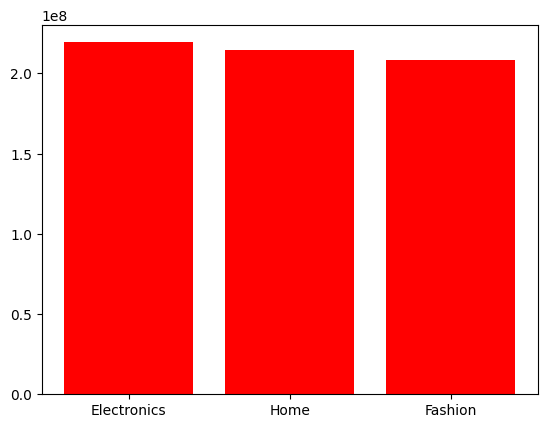

In [32]:
plt.bar(df_categoria_ordenada['category'], df_categoria_ordenada['total_sales'], color='red')